-*- encoding: utf-8 -*-
This file is part of GaPSE
Copyright (C) 2022 Matteo Foglieni
GaPSE is free software: you can redistribute it and/or modify
it under the terms of the GNU General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.
GaPSE is distributed in the hope that it will be useful, but
WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU
General Public License for more details.
You should have received a copy of the GNU General Public License
along with GaPSE. If not, see <http://www.gnu.org/licenses/>.

# deltachi_limits

Every $\chi$-integrated TPCF of GaPSE - the ones with a Lensing or an Integrated-GP leg -
has an integrand that is singular where the two integration points meet: the coefficients
$J$ carry powers of $\Delta\chi^{-4}$, the integrals $I_\ell^n(\Delta\chi)$ that multiply
them diverge, and only the product has a finite limit.

GaPSE therefore evaluates an **analytic** $\Delta\chi \rightarrow 0$ limit instead of the
$J \cdot I_\ell^n$ sum as soon as

$$ \Delta\chi \; < \; \min\left(\Delta\chi_\mathrm{min}, \;
   \Delta\chi_\mathrm{min} \cdot \max(\chi_1, \chi_2)\right) \; ,
   \qquad \Delta\chi_\mathrm{min} = 10^{-1} \;\; \text{by default,} $$

and the nine integrands that need one all switch on that same condition. This notebook
asks how visible that switch is, on the two auto-correlations:

- **Lensing-Lensing**, whose limit is $3 \sigma_2 + \frac{6}{5} \chi_1^2 \sigma_0$;
- **IntegratedGP-IntegratedGP**, whose limit is simply **zero**, because its prefactor
  $9 \Delta\chi^4$ kills the $\tilde{I}_0^4(\Delta\chi)$ that diverges.

and then measures what the choice of $\Delta\chi_\mathrm{min}$ costs in the integrated
TPCF, which is the only place where it can matter.

**How the singularity is approached.** A single number $\Delta\chi$ does not fix a
configuration, so we walk in along the straight line

$$ \chi_2 = \chi_1 + p \, \Delta\chi \; , \qquad
   y = 1 - \frac{\Delta\chi^2 \, (1 - p^2)}{2 \, \chi_1 \chi_2} \; , $$

the inverse of $\Delta\chi^2 = \chi_1^2 + \chi_2^2 - 2 \chi_1 \chi_2 y$. Below we take
$p = 1$, i.e. $y = 1$ exactly: a purely radial separation, the only direction that is
representable in `Float64` down to any $\Delta\chi$.

In [1]:
"""
    help(x)

Show the docstring of `x`. Useful in VSCode or Jupyter Lab, where prepending `?` doesn't work.
"""
macro help(x)
    quote
        display("text/markdown", @doc $x)
    end
end;
@help @help

```julia
help(x)
```

Show the docstring of `x`. Useful in VSCode or Jupyter Lab, where prepending `?` doesn't work.


## GaPSE setup

In [2]:
using GaPSE
using Plots, LaTeXStrings, QuadGK, Printf

# GR, the default Plots backend: it needs no Python at all, and it is the one that
# works under Julia 1.12 - see the "Which backend" section of ../ipynbs/README.md
gr()

Plots.GRBackend()

In [3]:
const PATH_TO_GAPSE = normpath(joinpath(@__DIR__, ".."));
const DIR = joinpath(@__DIR__, "deltachi_limits");
@assert isdir(DIR) "ERROR: DIR=$DIR DOESN'T EXIST!!!"

function save_plot(p, name)
    savefig(p, joinpath(DIR, name))
    nothing
end;

In [4]:
# the same `Cosmology` as the TUTORIAL, i.e. the z = 0.05 - 0.20 survey
const PARAMS = GaPSE.CosmoParams(0.05, 0.20, π / 2.0;
    Ω_b=0.0489, Ω_cdm=0.251020, h_0=0.70, s_lim=1e-2, z_spline_lim=1000.0,
    b1=1.0, s_b1=0.0, 𝑓_evo1=0.0,
    IPS_opts=Dict(:fit_left_min => 1e-6, :fit_left_max => 3e-6,
        :fit_right_min => 1e1, :fit_right_max => 2e1),
    IPSTools_opts=Dict(:N => 1024, :fit_min => 0.05, :fit_max => 0.5, :con => true,
        :k_min => 1e-8, :k_max => 10.0));

const COSMO = GaPSE.Cosmology(PARAMS,
    joinpath(PATH_TO_GAPSE, "data", "WideA_ZA_background.dat"),
    joinpath(PATH_TO_GAPSE, "data", "WideA_ZA_pk.dat"),
    joinpath(PATH_TO_GAPSE, "data", "F_REFERENCE_pi2.txt"),
    joinpath(PATH_TO_GAPSE, "data", "IntegrF_REFERENCE_pi2_z005020.txt"));

@printf("s_eff = %.3f Mpc/h   z_eff = %.4f\n", COSMO.s_eff, COSMO.z_eff)
@printf("σ_0 = %.5e   σ_2 = %.5e   (k = %.0e .. %.0e)\n",
    COSMO.tools.σ_0, COSMO.tools.σ_2, COSMO.tools.k_min, COSMO.tools.k_max)

s_eff = 435.375 Mpc/h   z_eff = 0.1505
σ_0 = 1.85843e+01   σ_2 = 1.01064e+02   (k = 1e-08 .. 1e+01)


## The two branches, and the plot functions

In [5]:
# The two galaxies sit at s1 = s2 = s_eff and the two integration points at
# χ1 = 0.3 s_eff and χ2 = χ1 + p Δχ, with y fixed by the parametrisation.
const S = COSMO.s_eff;
const CHI1 = 0.3 * S;

"the positional arguments of the scalar method of a double-χ integrand, at (Δχ, p)"
function args_of(Δχ, p)
    χ2 = CHI1 + p * Δχ
    y = 1 - Δχ^2 * (1 - p^2) / (2 * CHI1 * χ2)
    (CHI1, χ2, S, S, y)
end

# Δχ_min = 0 makes an integrand always take the J ⋅ I_l^n branch, Δχ_min = Inf always
# the analytic limit: both compare Δχ with min(Δχ_min, Δχ_min * max(χ1, χ2)).
jisum(f, Δχ, p=1.0) = f(args_of(Δχ, p)..., COSMO; Δχ_min=0.0)
dclimit(f, Δχ, p=1.0) = f(args_of(Δχ, p)..., COSMO; Δχ_min=Inf)

# the Δχ the switch really happens at, for this configuration
threshold(Δχ_min) = min(Δχ_min, Δχ_min * max(CHI1, CHI1 + Δχ_min));
@printf("with Δχ_min = 1e-1 the switch is at Δχ = %.3e\n", threshold(1e-1))

with Δχ_min = 1e-1 the switch is at Δχ = 1.000e-01


In [6]:
function plot_kwargs(kwargs...)
    defaults = Dict(
        :size => (1000, 560), :dpi => 200, :legendposition => :outerright,
        :legendfontsize => 10, :guidefontsize => 13, :tickfontsize => 10,
        :titlefontsize => 15, :left_margin => 18Plots.mm,
        :bottom_margin => 6Plots.mm, :yguidefontrotation => -90,
    )
    merge(defaults, Dict(kwargs))
end

# the ylabel is rotated horizontal, so it needs some room on its right
hlabel(s; pad=4) = s * " "^pad

logticks(lo, hi; step=1) = 10.0 .^ (floor(Int, log10(lo)):step:ceil(Int, log10(hi)))

logticks (generic function with 1 method)

In [7]:
"""
    branches_plot(f; p=1.0, Δχs, Δχ_min=1e-1, title="", ratio=true, toppad=6)

Upper panel: the absolute value of the integrand `f`, evaluated with the `J ⋅ I_l^n` sum
(dashed blue) and with the `Δχ → 0` limit (solid red), against `Δχ`. The dotted vertical
line is where the code switches from the first to the second.

With `ratio = true` a second, smaller panel shows `limit / sum` in green; it is useless
when the limit is exactly zero, hence the flag.

Absolute values, because the two branches can have opposite signs - and because a
logarithmic axis is the only one on which both ends of this range are visible.
"""
function branches_plot(f; p=1.0, Δχs=10 .^ range(-6, 2, length=400), Δχ_min=1e-1,
                       title="", ratio=true, toppad=6)
    vs = [jisum(f, Δχ, p) for Δχ in Δχs]
    vl = [dclimit(f, Δχ, p) for Δχ in Δχs]
    th = threshold(Δχ_min)
    lo = max(minimum(x -> x > 0 ? x : Inf, abs.(vs)), 1e-30)

    top = plot(; xscale=:log10, yscale=:log10, ylabel=hlabel("|integrand|"),
        title=title, xticks=logticks(Δχs[1], Δχs[end]),
        xlabel=ratio ? "" : L"\Delta\chi \; [h^{-1} \, \mathrm{Mpc}]",
        plot_kwargs(:bottom_margin => (ratio ? 0Plots.mm : 6Plots.mm))...)
    vline!(top, [th]; c=:black, ls=:dot, lw=2, label="switch" * " "^toppad)
    plot!(top, Δχs, abs.(vs); label="J ⋅ I_l^n sum" * " "^toppad, c=:blue, ls=:dash, lw=3)
    all(iszero, vl) ||
        plot!(top, Δχs, abs.(vl); label="Δχ → 0 limit" * " "^toppad, c=:red, lw=2)
    ratio || return plot(top; size=(1000, 500))

    bot = plot(; xscale=:log10, yscale=:log10, ylims=(1e-3, 1e3),
        xlabel=L"\Delta\chi \; [h^{-1} \, \mathrm{Mpc}]", ylabel=hlabel("ratio"),
        xticks=logticks(Δχs[1], Δχs[end]), yticks=logticks(1e-3, 1e3), plot_kwargs()...)
    hline!(bot, [1.0]; c=:black, ls=:dash, lw=2, alpha=0.55, label="")
    vline!(bot, [th]; c=:black, ls=:dot, lw=2, label="")
    plot!(bot, Δχs, abs.(vl ./ vs); label="limit / sum", c=:green, lw=3)

    plot(top, bot; layout=grid(2, 1, heights=[0.70, 0.30]), size=(1000, 620), link=:x)
end;
@help branches_plot

```julia
branches_plot(f; p=1.0, Δχs, Δχ_min=1e-1, title="", ratio=true, toppad=6)
```

Upper panel: the absolute value of the integrand `f`, evaluated with the `J ⋅ I_l^n` sum (dashed blue) and with the `Δχ → 0` limit (solid red), against `Δχ`. The dotted vertical line is where the code switches from the first to the second.

With `ratio = true` a second, smaller panel shows `limit / sum` in green; it is useless when the limit is exactly zero, hence the flag.

Absolute values, because the two branches can have opposite signs - and because a logarithmic axis is the only one on which both ends of this range are visible.


## GNC Lensing-Lensing

Both legs are integrated, all four $J$ coefficients carry a $\Delta\chi^{-4}$, and the
limit of the square bracket is $3\sigma_2 + \frac{6}{5}\chi_1^2\sigma_0$. The prefactor is
the same on both sides of the switch, so the ratio below is the ratio of the brackets
alone.

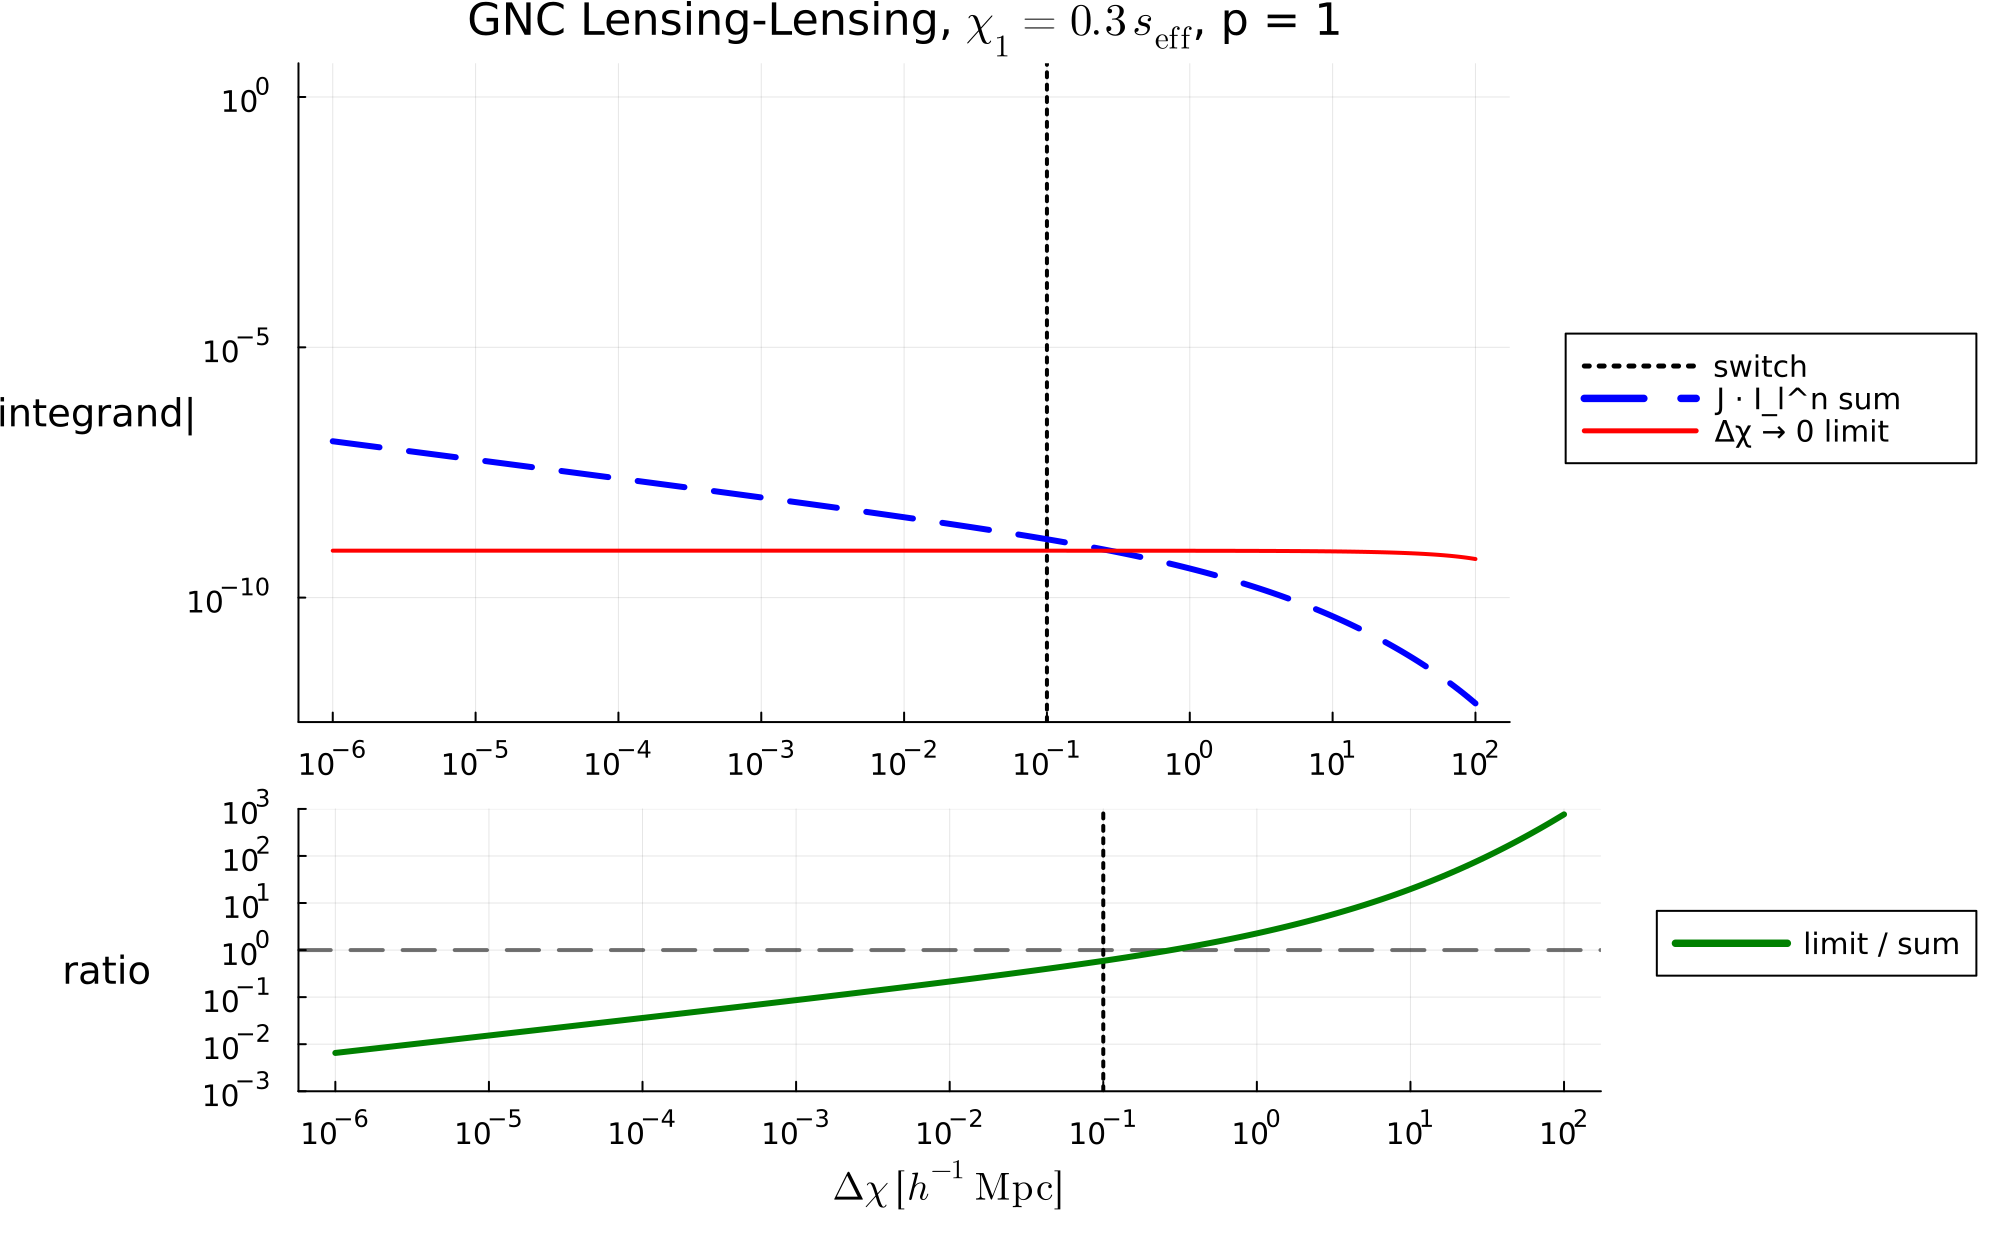

In [8]:
p_LL = branches_plot(GaPSE.integrand_ξ_GNC_Lensing;
    title="GNC Lensing-Lensing, " * L"\chi_1 = 0.3 \, s_{\mathrm{eff}}" * ", p = 1")
save_plot(p_LL, "lensing_lensing_branches.png")
p_LL

In [9]:
let Δχ_min = 1e-1
    s = jisum(GaPSE.integrand_ξ_GNC_Lensing, Δχ_min)
    l = dclimit(GaPSE.integrand_ξ_GNC_Lensing, Δχ_min)
    @printf("at the switch, Δχ = %.0e :\n", Δχ_min)
    @printf("  J ⋅ I_l^n sum   %+.5e\n  Δχ → 0 limit    %+.5e\n", s, l)
    @printf("  relative step   %+.2f %%\n  absolute step   %+.3e\n",
        100 * (l / s - 1), l - s)
end

at the switch, Δχ = 1e-01 :
  J ⋅ I_l^n sum   +1.46660e-09
  Δχ → 0 limit    +8.65422e-10
  relative step   -40.99 %
  absolute step   -6.012e-10


The two branches do not meet: at the switch they differ by some tens of percent,
and below it the limit is flat - as it must be, depending only on $\chi_1$ and on the
$\sigma_i$ - while the sum keeps growing. The next section says why, and it is not a
mistake in the limit.

## GNC IntegratedGP-IntegratedGP

Here the whole integrand is

$$ 9 \, \Delta\chi^4 \; \mathcal{H}_0^4 \, \Omega_{M0}^2 \; \frac{D_1 D_2}{s_1 s_2 a_1 a_2}
   \; (\ldots)_1 (\ldots)_2 \; \tilde{I}_0^4(\Delta\chi) \; , $$

and $\Delta\chi^4 \, \tilde{I}_0^4(\Delta\chi) \rightarrow 0$, so the limit branch returns
exactly zero and there is nothing to take a ratio with. The only question is how large the
term being dropped still is at the switch.

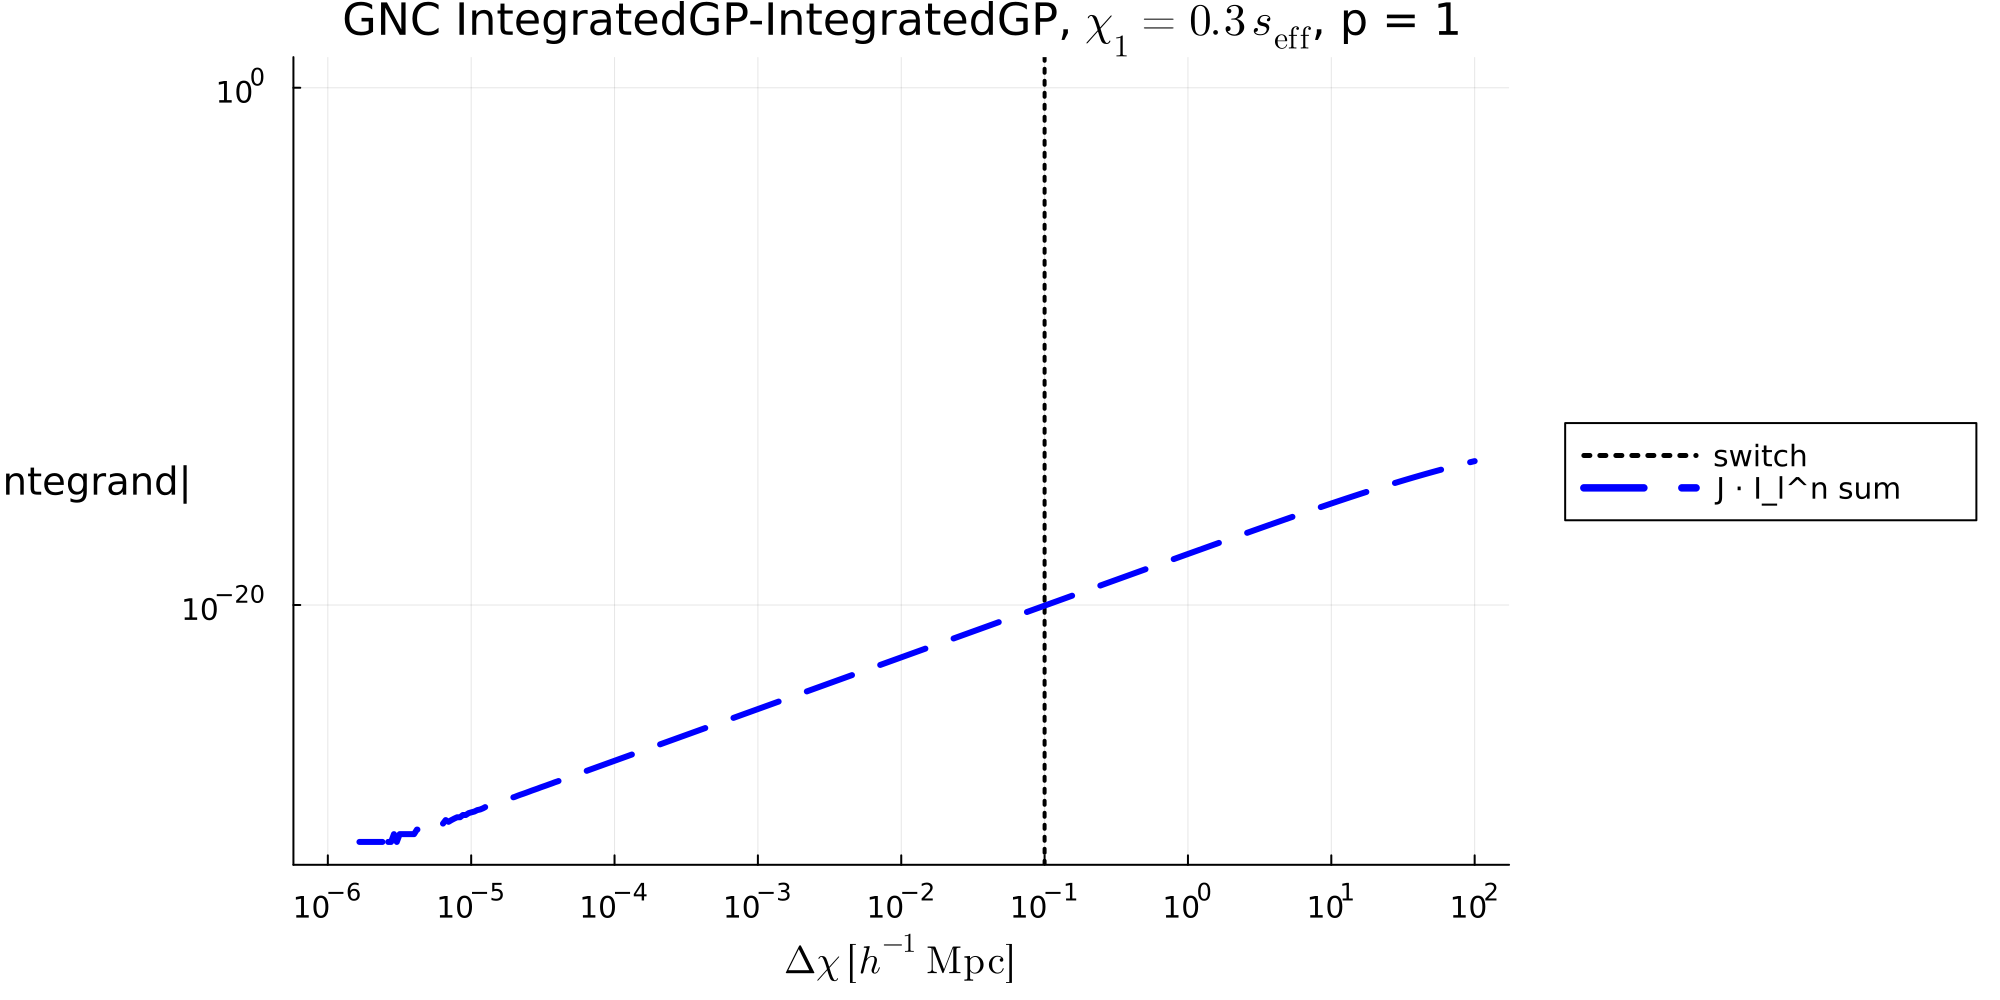

In [10]:
p_IGP = branches_plot(GaPSE.integrand_ξ_GNC_IntegratedGP; ratio=false,
    title="GNC IntegratedGP-IntegratedGP, " * L"\chi_1 = 0.3 \, s_{\mathrm{eff}}" * ", p = 1")
save_plot(p_IGP, "intgp_intgp_branches.png")
p_IGP

In [11]:
let Δχ_min = 1e-1
    @printf("%s | %14s %14s\n", lpad("Δχ", 9), "IntGP-IntGP", "Lens-Lens")
    for Δχ in [1e0, Δχ_min, 1e-2, 1e-3, 1e-4]
        @printf("%9.0e | %+14.4e %+14.4e\n", Δχ,
            jisum(GaPSE.integrand_ξ_GNC_IntegratedGP, Δχ),
            jisum(GaPSE.integrand_ξ_GNC_Lensing, Δχ))
    end
    @printf("\nat the switch the dropped term is %+.3e, against the %+.3e of\n",
        jisum(GaPSE.integrand_ξ_GNC_IntegratedGP, Δχ_min),
        jisum(GaPSE.integrand_ξ_GNC_Lensing, Δχ_min))
    println("Lensing-Lensing in the very same configuration")
end

       Δχ |    IntGP-IntGP      Lens-Lens
    1e+00 |    -9.3974e-19    +3.8165e-10
    1e-01 |    -9.4552e-21    +1.4666e-09
    1e-02 |    -9.4625e-23    +4.0309e-09
    1e-03 |    -9.4698e-25    +1.0020e-08
    1e-04 |    -9.4813e-27    +2.4002e-08

at the switch the dropped term is -9.455e-21, against the +1.467e-09 of
Lensing-Lensing in the very same configuration


So this switch is a discontinuity of 100% - from something to exactly zero - on a
quantity that is already twelve orders of magnitude below the Lensing-Lensing integrand
next to it. Relative steps are the wrong thing to look at here; absolute ones are
$10^{-20}$.

## Why Lensing-Lensing jumps: $\sigma_0$ does not converge

The limit is a combination of the moments

$$ \sigma_i \; = \; \int_{k_\mathrm{min}}^{k_\mathrm{max}} \frac{\mathrm{d}q}{2\pi^2}
   \; q^{\,2-i} \, P(q) \; , $$

and the two that appear in it are not on the same footing.
$\sigma_2 = \int \mathrm{d}q \, P / 2\pi^2$ converges, since $P \sim q^{-3}$ at large $q$;
$\sigma_0 = \int \mathrm{d}q \, q^2 P / 2\pi^2$ does not, and its value is set by the cut
$k_\mathrm{max}$ itself - which is what the `sigma_i` notebook is about.

The two sides of the switch cut that divergence differently: the **limit** uses
`cosmo.tools.σ_0`, cut at the `k_max` of `IPSTools_opts`, while the **sum** uses
$I_2^2(\Delta\chi) \rightarrow \sigma_0/15$, cut by $\Delta\chi$ itself, because
$j_2(q\Delta\chi)/(q\Delta\chi)^2$ stops the integrand at $q \sim 1/\Delta\chi$. They can
only agree where $k_\mathrm{max} \simeq 1/\Delta\chi$.

In [12]:
# the two asymptotics the Lensing-Lensing limit is made of, against the moments
# they are supposed to reach
@printf("%s | %s %s | %s %s\n", lpad("Δχ", 9),
    lpad("9Δχ² I13(Δχ)", 13), lpad("/ 3σ_2", 9),
    lpad("15 I22(Δχ)", 13), lpad("/ σ_0", 9))
for Δχ in [1e0, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
    a = 9 * Δχ^2 * COSMO.tools.I13(Δχ)
    b = 15 * COSMO.tools.I22(Δχ)
    @printf("%9.0e | %13.5e %9.4f | %13.5e %9.3f\n",
        Δχ, a, a / (3 * COSMO.tools.σ_2), b, b / COSMO.tools.σ_0)
end

# and the same σ_i taken over the range the I_l^n themselves come from
IPS = GaPSE.InputPS(joinpath(PATH_TO_GAPSE, "data", "WideA_ZA_pk.dat");
    fit_left_min=1e-6, fit_left_max=3e-6, fit_right_min=1e1, fit_right_max=2e1)
σ(i, kmin, kmax) = quadgk(q -> IPS(q) * q^(2 - i) / (2 * π^2), kmin, kmax)[1]
@printf("\nσ_0 over k = %.0e .. %.0e (cosmo.tools) : %.5e\n",
    COSMO.tools.k_min, COSMO.tools.k_max, COSMO.tools.σ_0)
@printf("σ_0 over k = 1e-5 .. 1e3 (the xicalc call) : %.5e   -> a factor %.2f\n",
    σ(0, 1e-5, 1e3), σ(0, 1e-5, 1e3) / COSMO.tools.σ_0)
@printf("σ_2 over the same two ranges               : %.5e  %.5e\n",
    COSMO.tools.σ_2, σ(2, 1e-5, 1e3))

       Δχ |  9Δχ² I13(Δχ)    / 3σ_2 |    15 I22(Δχ)     / σ_0
    1e+00 |   2.99791e+02    0.9888 |   8.14841e+00     0.438
    1e-01 |   3.03262e+02    1.0002 |   3.14803e+01     1.694
    1e-02 |   3.03441e+02    1.0008 |   8.65835e+01     4.659
    1e-03 |   3.03561e+02    1.0012 |   2.15255e+02    11.583
    1e-04 |   3.03680e+02    1.0016 |   5.15668e+02    27.748
    1e-05 |   3.03799e+02    1.0020 |   1.21705e+03    65.488
    1e-06 |   3.03918e+02    1.0024 |   2.85457e+03   153.601

σ_0 over k = 1e-08 .. 1e+01 (cosmo.tools) : 1.85843e+01
σ_0 over k = 1e-5 .. 1e3 (the xicalc call) : 1.43285e+02   -> a factor 7.71
σ_2 over the same two ranges               : 1.01064e+02  1.01128e+02


The $\sigma_2$ half of the limit is reached to one part in $10^4$ already at
$\Delta\chi = 10^{-1}$ and stays there. The $\sigma_0$ half never settles: it is $1.7$
times `cosmo.tools.σ_0` at the switch and keeps climbing by a factor $\simeq 2.4$ per
decade, because every decade of $\Delta\chi$ opens a decade of $q$ that a moment cut at
$k_\mathrm{max} = 10$ does not contain.

Two things follow.

- $\Delta\chi_\mathrm{min}$ should not be as small as possible, but
  $\simeq 1/k_\mathrm{max}$. With the defaults used here, $k_\mathrm{max} = 10$ and
  $\Delta\chi_\mathrm{min} = 10^{-1}$, those are the same number, and the residual factor
  $1.7$ is just how soft a cut the $j_2$ kernel is. Lowering
  $\Delta\chi_\mathrm{min}$ makes the step **larger**, not smaller.
- Worth a look, separately from these limits: `cosmo.tools.σ_i` is cut at the
  `k_min, k_max` of `IPSTools_opts`, while the $I_\ell^n$ come from a `xicalc` call that
  hard-codes `kmin = 1e-5, kmax = 1e3`. For $\sigma_0$ the two ranges differ by a factor
  7.7, and the moments of the limits and the integrals of the sums should be cut at the
  same place.

## What it costs in the integral

The switch happens in a shell of thickness $\Delta\chi_\mathrm{min} = 0.1$ around the
diagonal of a domain hundreds of $h^{-1}$Mpc wide, and `ξ_GNC_Lensing` samples it with
`N_χs_2 = 100` points per side, i.e. a step of $s_\mathrm{eff}/100 \simeq 4$. The
quadrature therefore enters that shell only when $y$ is close enough to 1 for the two
lines of sight to nearly coincide. This table is what decides whether anything above
matters.

In [13]:
let ref_min = 1e-1, tries = (1e0, 1e-2, 1e-3, 1e-5)
    @printf("ξ_GNC_Lensing, relative change with respect to Δχ_min = %.0e\n\n", ref_min)
    @printf("  %7s %14s | %14s", "s2/s1", "y", @sprintf("Δχ_min=%.0e", ref_min))
    foreach(d -> @printf(" %11s", @sprintf("%.0e", d)), tries)
    println()
    for (s1, s2) in ((S, S), (S, 0.9S)), y in (0.5, 0.99, 1.0 - 1e-6, 1.0)
        r = GaPSE.ξ_GNC_Lensing(s1, s2, y, COSMO; Δχ_min=ref_min)
        @printf("  %7.2f %14.8f | %+14.5e", s2 / s1, y, r)
        for d in tries
            v = GaPSE.ξ_GNC_Lensing(s1, s2, y, COSMO; Δχ_min=d)
            @printf(" %+10.3f%%", 100 * (v / r - 1))
        end
        println()
    end
end

ξ_GNC_Lensing, relative change with respect to Δχ_min = 1e-01

    s2/s1              y |   Δχ_min=1e-01       1e+00       1e-02       1e-03       1e-05
     1.00     0.50000000 |   -1.57443e-09     -0.207%     +0.000%     +0.000%     +0.000%
     1.00     0.99000000 |   +8.53029e-08     +0.030%     +0.000%     +0.000%     +0.000%
     1.00     0.99999900 |   +1.55484e-06    +32.987%     +0.967%     +0.975%     +0.975%
     1.00     1.00000000 |   +2.07103e-06     +0.000%     +0.000%     +0.000%     +0.000%
     0.90     0.50000000 |   -1.38654e-09     -0.212%     +0.000%     +0.000%     +0.000%
     0.90     0.99000000 |   +7.87724e-08     +0.030%     +0.000%     +0.000%     +0.000%
     0.90     0.99999900 |   +1.11800e-06    +22.445%     +0.102%     +0.102%     +0.102%
     0.90     1.00000000 |   +1.22270e-06    +13.307%     +0.000%     +0.000%   +323.101%


And this is the answer. **Moving $\Delta\chi_\mathrm{min}$ down by one, two or three
orders of magnitude leaves the integrated TPCF unchanged** - exactly $0.000\%$ in most
configurations, and about $1\%$ in the one where $y = 1 - 10^{-6}$ puts the two lines of
sight almost on top of each other and the quadrature really does walk along the diagonal.
The tens of percent of the integrand at the switch live in a shell of measure
$\sim 10^{-4}$ of the domain, and come out as $10^{-5}$ or less.

The two ends of the table also show that the default is not an arbitrary choice:

- $\Delta\chi_\mathrm{min} = 1$ is ten times too large and biases the result by 13% to
  33% when $y \rightarrow 1$: the limit is used where the expansion does not hold;
- $\Delta\chi_\mathrm{min} = 10^{-5}$ is too small, and the last row shows the price -
  $+323\%$, because the $J \cdot I_\ell^n$ sum is then evaluated at
  $\Delta\chi \sim 10^{-6}$, where it is nothing but the $\Delta\chi^{-4}$ cancellation.
  The limit branch is not an optimisation: it is what keeps the quadrature finite.

## Summary

- **Lensing-Lensing** switches with a step of some tens of percent on the integrand. It is
  not an error in the limit: $\sigma_0$ is `k_max`-dependent, the sum cuts that divergence
  with $\Delta\chi$ and the limit with `IPSTools_opts[:k_max]`, and the two agree only
  where $\Delta\chi_\mathrm{min} \simeq 1/k_\mathrm{max}$ - which the defaults
  $10^{-1}$ and $10$ already satisfy.
- **IntegratedGP-IntegratedGP** switches to exactly zero, so the step is 100% of an
  integrand that is $10^{-21}$ there: an absolute step of $10^{-20}$, against the
  $10^{-9}$ of the effects beside it.
- **In the integral neither is visible**: `ξ_GNC_Lensing` does not move at all for
  $\Delta\chi_\mathrm{min}$ between $10^{-1}$ and $10^{-3}$, and moves by $\simeq 1\%$
  only in the nearly-collinear corner. A ten times larger threshold is measurably wrong,
  and a $10^4$ times smaller one is catastrophically so.

## END